## Setup

In [ ]:
# # Copy the stuff from Drive to local Colab storage (Fast)
# !cp "/content/drive/MyDrive/NIT Colab Notebooks/data/hvoice-fake-voice.zip" "/content/"
# !mkdir -p "/content/4 Deep4SNet Model"
# !mkdir -p "/content/plots"
# !cp -r "/content/drive/MyDrive/NIT Colab Notebooks/4 Deep4SNet Model"/* "/content/4 Deep4SNet Model/"

!mkdir -p data
!mkdir -p "4 Deep4SNet Model"
# Download the dataset and weights
!wget -q -O hvoice-fake-voice.zip "https://raw.githubusercontent.com/msr8/NIT/refs/heads/main/data/hvoice-fake-voice.zip"
!wget -q -O "4 Deep4SNet Model/model_Deep4SNet.h5" "https://raw.githubusercontent.com/msr8/NIT/refs/heads/main/4%20Deep4SNet%20Model/model_Deep4SNet.h5"
# Unzip it locally
!unzip -qq -o hvoice-fake-voice.zip -d data
!rm hvoice-fake-voice.zip

# Plot stuff
!rm plots/4*
!mkdir -p plots

# print("Current working directory:", os.getcwd())

In [8]:
# To force torchinfo to use cpu, cause even when using .to(dev), it wasnt working >:(
import os
os.environ["HIP_VISIBLE_DEVICES"]  = "" 
os.environ["ROCR_VISIBLE_DEVICES"] = ""

# pip install torch h5py numpy matplotlib scikit-learn opencv-python-headless kagglehub
import pathlib
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay


DATA_ROOT = pathlib.Path("data/hvoice-fake-voice")
H5_PATH   = '4 Deep4SNet Model/model_Deep4SNet.h5'


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)

torch 2.9.1 | device: cpu


# Copy the weights of Deep4SNet model

In [ ]:
import h5py

class Deep4SNet(nn.Module):
    """PyTorch port of the Keras Deep4SNet classifier (single sigmoid output)"""
    def __init__(self, beta=10.0):
        super().__init__()
        self.c0   = nn.Conv2d(3, 32, 3)     # 'valid' padding == 0
        self.c1   = nn.Conv2d(32, 32, 3)
        self.c2   = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2)
        self.fc   = nn.Linear(18496, 64)
        self.out  = nn.Linear(64, 1)
        self.beta = beta

    def act(self, z):
        return F.softplus(z, beta=self.beta)

    def forward(self, x):
        h = self.pool(self.act(self.c0(x)))
        h = self.pool(self.act(self.c1(h)))
        h = self.pool(self.act(self.c2(h)))
        h = h.permute(0, 2, 3, 1).reshape(h.size(0), -1)   # NCHW -> NHWC -> flat (Keras order)
        h = self.act(self.fc(h))
        return torch.sigmoid(self.out(h))


def load_keras_weights(model, h5_path):
    with h5py.File(h5_path, "r") as f:
        mw = f["model_weights"]
        def w(p): return np.array(mw[p])
        with torch.no_grad():
            # Conv2D kernels: Keras (kh,kw,in,out) -> torch (out,in,kh,kw)
            model.c0.weight.copy_(torch.tensor(w("conv2d/conv2d/kernel:0").transpose(3,2,0,1)))
            model.c0.bias.copy_(torch.tensor(w("conv2d/conv2d/bias:0")))
            model.c1.weight.copy_(torch.tensor(w("conv2d_1/conv2d_1/kernel:0").transpose(3,2,0,1)))
            model.c1.bias.copy_(torch.tensor(w("conv2d_1/conv2d_1/bias:0")))
            model.c2.weight.copy_(torch.tensor(w("conv2d_2/conv2d_2/kernel:0").transpose(3,2,0,1)))
            model.c2.bias.copy_(torch.tensor(w("conv2d_2/conv2d_2/bias:0")))
            # Dense kernels: Keras (in,out) -> torch (out,in)
            model.fc.weight.copy_(torch.tensor(w("dense/dense/kernel:0").T))
            model.fc.bias.copy_(torch.tensor(w("dense/dense/bias:0")))
            model.out.weight.copy_(torch.tensor(w("dense_1/dense_1/kernel:0").T))
            model.out.bias.copy_(torch.tensor(w("dense_1/dense_1/bias:0")))
    return model


# model = load_keras_weights(Deep4SNet(), H5_PATH).to(DEVICE).eval()
model = load_keras_weights(Deep4SNet(beta=10.0), H5_PATH).to(DEVICE).eval()
print(summary(model, input_size=(1, 3, 150, 150), col_names=["input_size", "output_size", "num_params", "trainable"]))
print("params:", sum(p.numel() for p in model.parameters()))
torch.save(model.state_dict(), "4 Deep4SNet Model/deep4snet.pt")

# sanity: output is a valid probability
with torch.no_grad():
    t = torch.rand(2, 3, 150, 150, device=DEVICE)
    print("sample outputs:", model(t).squeeze(1).tolist())

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
Deep4SNet                                [1, 3, 150, 150]          [1, 1]                    --                        True
├─Conv2d: 1-1                            [1, 3, 150, 150]          [1, 32, 148, 148]         896                       True
├─MaxPool2d: 1-2                         [1, 32, 148, 148]         [1, 32, 74, 74]           --                        --
├─Conv2d: 1-3                            [1, 32, 74, 74]           [1, 32, 72, 72]           9,248                     True
├─MaxPool2d: 1-4                         [1, 32, 72, 72]           [1, 32, 36, 36]           --                        --
├─Conv2d: 1-5                            [1, 32, 36, 36]           [1, 64, 34, 34]           18,496                    True
├─MaxPool2d: 1-6                         [1, 64, 34, 34]           [1, 64, 17, 17]           --                        --
├─Linear:

## Verify the existence of h-voice dataset

In [10]:
def locate(name):
    """Find a split folder by name, wherever it sits in the download tree."""
    hits = [p for p in DATA_ROOT.rglob(name) if p.is_dir()]
    return hits[0] if hits else None



for n in ["Training_fake","Training_original","Validation_fake","Validation_original", "External_test1","External_test2"]:
    d = locate(n)
    cnt = len([*d.rglob("*")]) if d else 0
    print(f"{n:22s} {'-> '+str(d) if d else 'NOT FOUND':50s}  (~{cnt} files)")

Training_fake          -> data/hvoice-fake-voice/Training_fake             (~2088 files)
Training_original      -> data/hvoice-fake-voice/Training_original         (~2020 files)
Validation_fake        -> data/hvoice-fake-voice/Validation_fake           (~864 files)
Validation_original    -> data/hvoice-fake-voice/Validation_original       (~864 files)
External_test1         -> data/hvoice-fake-voice/External_test1            (~762 files)
External_test2         -> data/hvoice-fake-voice/External_test2            (~78 files)


## 4. Load + preprocess a test set

Images are read with OpenCV, converted to RGB (training used RGB via Keras' generator), resized to 150×150, and rescaled to [0,1].

Labels are inferred from the filename / folder: anything marked "fake" → `0`, "original" → `1`

In [11]:
IMG_EXT = {".png", ".jpg", ".jpeg", ".bmp"}
RESCALE = 1.0 / 255          # set to 1.0 to mimic the authors' (saturating) raw-pixel inference
TO_RGB  = True               # training used RGB; the authors' test script used BGR

def label_of(path: pathlib.Path):
    s = (str(path.parent.name) + "/" + path.name).lower()
    if "fake" in s:                                   return 0
    if "original" in s: return 1
    return None  # unknown -> skipped

def load_image(path):
    img = cv2.imread(str(path))
    if img is None: return None
    img = cv2.resize(img, (150, 150))
    if TO_RGB: img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.astype("float32") * RESCALE

def load_split(folder):
    X, y, paths = [], [], []
    for p in sorted(folder.rglob("*")):
        if p.suffix.lower() not in IMG_EXT: continue
        lab = label_of(p)
        if lab is None: continue
        arr = load_image(p)
        if arr is None: continue
        X.append(arr); y.append(lab); paths.append(p)
    X = torch.tensor(np.stack(X)).permute(0, 3, 1, 2)   # NHWC -> NCHW
    return X, torch.tensor(y), paths

## 5. Test the model

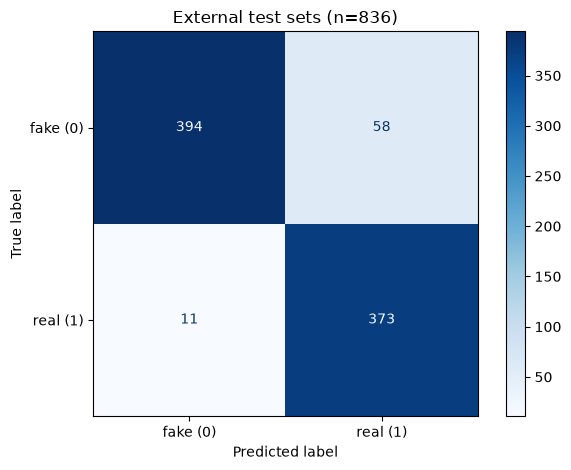

              precision    recall  f1-score   support

    fake (0)       0.97      0.87      0.92       452
    real (1)       0.87      0.97      0.92       384

    accuracy                           0.92       836
   macro avg       0.92      0.92      0.92       836
weighted avg       0.92      0.92      0.92       836



In [17]:
@torch.no_grad()
def predict_probs(model, X, batch=64):
    out = []
    for i in range(0, len(X), batch):
        out.append(model(X[i:i+batch].to(DEVICE)).squeeze(1).cpu())
    return torch.cat(out).numpy()


# Concatenate the two external test sets into one, and evaluate on that
x_test = []
y_test = []
for name in ["External_test1", "External_test2"]:
    folder = locate(name)
    if folder is None:
        print(f"[skip] {name} not found"); continue
    X, y, _ = load_split(folder)
    x_test.append(X)
    y_test.append(y)

x_test = torch.cat(x_test)
y_test = torch.cat(y_test)

pred = (predict_probs(model, x_test) > 0.5).astype(int)

cm   = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["fake (0)", "real (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f'External test sets (n={len(y_test)})')
plt.tight_layout()
plt.savefig('plots/4.1 Confusion Matrix.png', dpi=300)
plt.show()

print(classification_report(y_test.numpy(), pred, target_names=["fake (0)", "real (1)"]))

In [6]:
# # Zip the plots/ dir and make it available for download
# import shutil
# shutil.make_archive('plots', 'zip', 'plots')

# import base64
# print(base64.b64encode(open('/content/plots.zip','rb').read()).decode())